# 05 — Regularisation operators and potentials

The direct Dupire formula was unstable because it differentiated noisy prices.

Our main method will instead estimate a correction \(h\) to a reference
log-local-variance surface and penalise implausible corrections.

The regularisation penalty is

$$
h^\top R h,
$$

where

$$
R
=
\beta I
+
\alpha_x D_x^\top D_x
+
\alpha_T D_T^\top D_T
+
\operatorname{diag}(V).
$$

In this notebook, we construct and inspect each part of \(R\).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import eye
from scipy.sparse.linalg import eigsh, spsolve

from src.regularization.operators import (
    build_2d_difference_operators,
    build_regularization_matrix,
    regularization_components,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)


## 1. Calibration grid

The correction surface has shape

```text
(number of maturities, number of log-moneyness points)
```

Rows correspond to maturity and columns correspond to log-moneyness.

When flattened in C order, log-moneyness varies fastest.


In [3]:
x_grid = np.linspace(-0.40, 0.40, 25)
maturity_grid = np.linspace(0.10, 2.00, 15)

x_mesh, maturity_mesh = np.meshgrid(
    x_grid,
    maturity_grid,
)

delta_x = x_grid[1] - x_grid[0]
delta_T = maturity_grid[1] - maturity_grid[0]

number_of_maturities = maturity_grid.size
number_of_x_points = x_grid.size
number_of_unknowns = (
    number_of_maturities * number_of_x_points
)

print("Surface shape:", x_mesh.shape)
print("Number of unknown corrections:", number_of_unknowns)
print("Delta x:", delta_x)
print("Delta T:", delta_T)


Surface shape: (15, 25)
Number of unknown corrections: 375
Delta x: 0.033333333333333326
Delta T: 0.1357142857142857


## 2. Difference operators

\(D_x\) measures changes between neighbouring log-moneyness values:

$$
(D_xh)_{j,i}
\approx
\frac{h_{j,i+1}-h_{j,i}}{\Delta x}.
$$

\(D_T\) measures changes between neighbouring maturities:

$$
(D_Th)_{j,i}
\approx
\frac{h_{j+1,i}-h_{j,i}}{\Delta T}.
$$


In [4]:
D_x, D_T = build_2d_difference_operators(
    number_of_maturities=number_of_maturities,
    number_of_log_moneyness_points=number_of_x_points,
    maturity_spacing=delta_T,
    log_moneyness_spacing=delta_x,
)

print("D_x shape:", D_x.shape)
print("D_T shape:", D_T.shape)


D_x shape: (360, 375)
D_T shape: (350, 375)


## 3. Natural Neumann boundary behaviour

The difference operators penalise changes between neighbouring points, but
they do not force boundary values to zero.

Therefore a constant correction has zero roughness:

$$
D_xh=0,
\qquad
D_Th=0.
$$

This is the discrete natural or Neumann boundary treatment used in the
regulariser. The correction may be nonzero at the boundary, but the preferred
solution flattens there.


In [5]:
constant_correction = np.full(
    (number_of_maturities, number_of_x_points),
    0.05,
)
constant_vector = constant_correction.reshape(
    -1,
    order="C",
)

print(
    "Maximum absolute x-difference:",
    np.max(np.abs(D_x @ constant_vector)),
)
print(
    "Maximum absolute maturity-difference:",
    np.max(np.abs(D_T @ constant_vector)),
)

assert np.allclose(D_x @ constant_vector, 0.0)
assert np.allclose(D_T @ constant_vector, 0.0)


Maximum absolute x-difference: 0.0
Maximum absolute maturity-difference: 0.0


## 4. Smooth and rough corrections

The smooth surface changes gradually.

The rough surface contains alternating high-frequency changes. The
regulariser should assign a much larger roughness penalty to it.


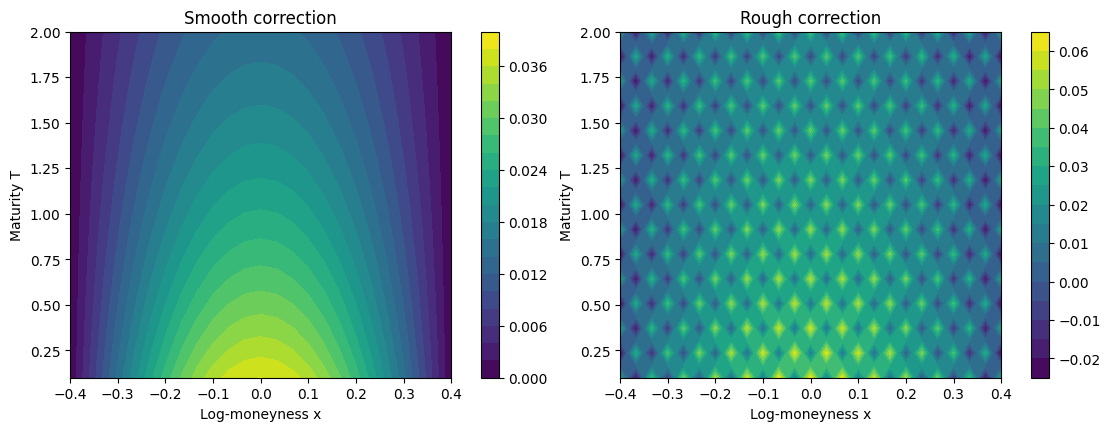

In [6]:
smooth_correction = (
    0.04
    * np.cos(np.pi * x_mesh / 0.8)
    * np.exp(-0.5 * maturity_mesh)
)

checkerboard = (
    (-1.0)
    ** (
        np.indices(smooth_correction.shape).sum(axis=0)
    )
)

rough_correction = (
    smooth_correction
    + 0.025 * checkerboard
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)

first = axes[0].contourf(
    x_grid,
    maturity_grid,
    smooth_correction,
    levels=20,
)
figure.colorbar(first, ax=axes[0])
axes[0].set_title("Smooth correction")
axes[0].set_xlabel("Log-moneyness x")
axes[0].set_ylabel("Maturity T")

second = axes[1].contourf(
    x_grid,
    maturity_grid,
    rough_correction,
    levels=20,
)
figure.colorbar(second, ax=axes[1])
axes[1].set_title("Rough correction")
axes[1].set_xlabel("Log-moneyness x")
axes[1].set_ylabel("Maturity T")

plt.show()


## 5. What the operators detect

After applying \(D_x\), the result lives between neighbouring \(x\)-points.

After applying \(D_T\), the result lives between neighbouring maturities.


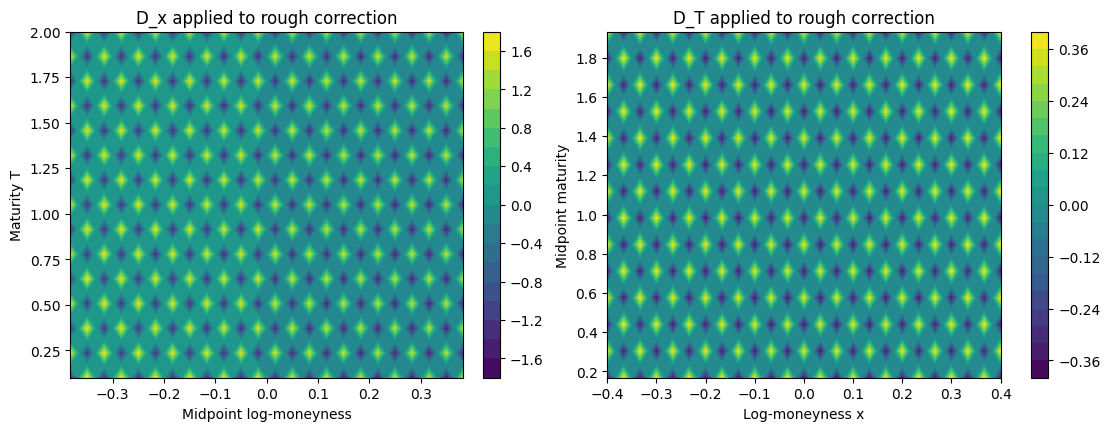

In [7]:
rough_vector = rough_correction.reshape(
    -1,
    order="C",
)

x_changes = (D_x @ rough_vector).reshape(
    number_of_maturities,
    number_of_x_points - 1,
    order="C",
)
time_changes = (D_T @ rough_vector).reshape(
    number_of_maturities - 1,
    number_of_x_points,
    order="C",
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)

first = axes[0].contourf(
    0.5 * (x_grid[:-1] + x_grid[1:]),
    maturity_grid,
    x_changes,
    levels=20,
)
figure.colorbar(first, ax=axes[0])
axes[0].set_title("D_x applied to rough correction")
axes[0].set_xlabel("Midpoint log-moneyness")
axes[0].set_ylabel("Maturity T")

second = axes[1].contourf(
    x_grid,
    0.5 * (
        maturity_grid[:-1]
        + maturity_grid[1:]
    ),
    time_changes,
    levels=20,
)
figure.colorbar(second, ax=axes[1])
axes[1].set_title("D_T applied to rough correction")
axes[1].set_xlabel("Log-moneyness x")
axes[1].set_ylabel("Midpoint maturity")

plt.show()


## 6. Wing potential

A wing potential discourages large corrections far away from the forward.

It does not force the correction to zero. It simply makes a correction more
expensive in regions where extrapolation is less reliable.


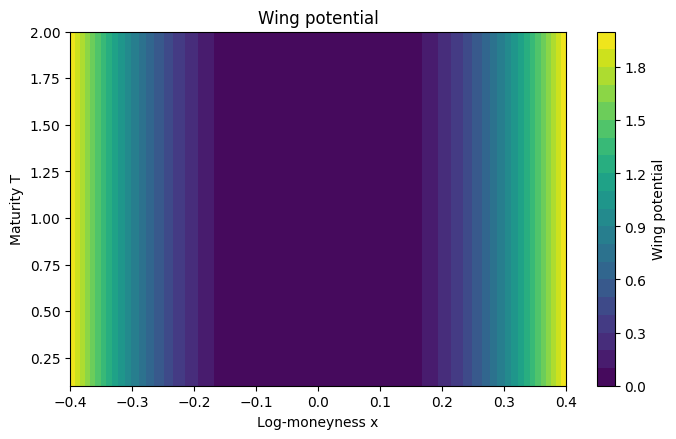

In [8]:
wing = wing_potential(
    log_moneyness=x_grid,
    maturities=maturity_grid,
    strength=2.0,
    power=2.0,
    start=0.10,
)

plt.figure(figsize=(8, 4.6))
contour = plt.contourf(
    x_grid,
    maturity_grid,
    wing,
    levels=20,
)
plt.colorbar(contour, label="Wing potential")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Wing potential")
plt.show()


## 7. Quote-confidence potential

We create a confidence surface from nearby quote density.

Confidence is high near quote locations and low in sparse regions. The
confidence potential is

$$
V_{\mathrm{confidence}}
=
\gamma_c(1-\mathrm{confidence})^p.
$$

Therefore, corrections are penalised more strongly where the data provide less
information.


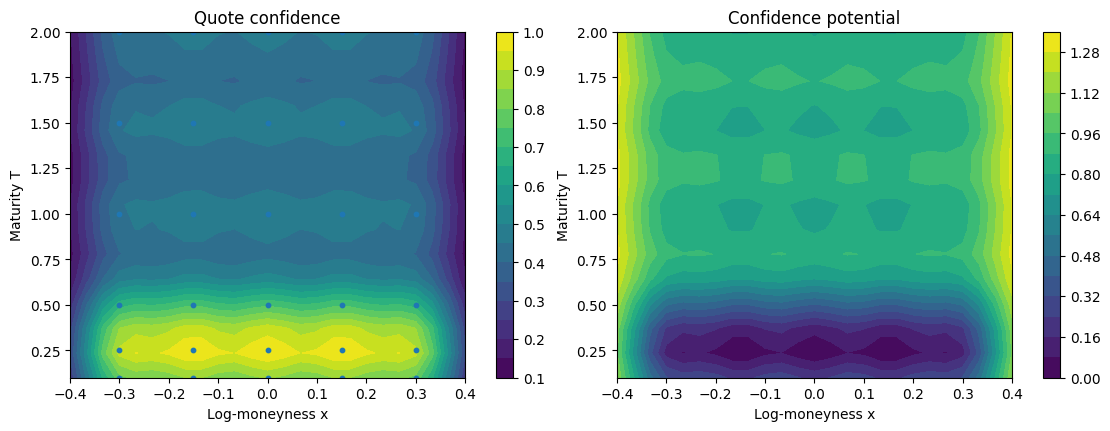

In [9]:
quote_x_values = np.array(
    [-0.30, -0.15, 0.00, 0.15, 0.30]
)
quote_maturities = np.array(
    [0.10, 0.25, 0.50, 1.00, 1.50, 2.00]
)

quote_x_mesh, quote_T_mesh = np.meshgrid(
    quote_x_values,
    quote_maturities,
)

confidence = quote_confidence_surface(
    log_moneyness=x_grid,
    maturities=maturity_grid,
    quote_log_moneyness=quote_x_mesh.reshape(-1),
    quote_maturities=quote_T_mesh.reshape(-1),
    log_moneyness_bandwidth=0.07,
    maturity_bandwidth=0.20,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=1.5,
    power=1.0,
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)

first = axes[0].contourf(
    x_grid,
    maturity_grid,
    confidence,
    levels=20,
)
figure.colorbar(first, ax=axes[0])
axes[0].scatter(
    quote_x_mesh.reshape(-1),
    quote_T_mesh.reshape(-1),
    s=10,
)
axes[0].set_title("Quote confidence")
axes[0].set_xlabel("Log-moneyness x")
axes[0].set_ylabel("Maturity T")

second = axes[1].contourf(
    x_grid,
    maturity_grid,
    confidence_penalty,
    levels=20,
)
figure.colorbar(second, ax=axes[1])
axes[1].set_title("Confidence potential")
axes[1].set_xlabel("Log-moneyness x")
axes[1].set_ylabel("Maturity T")

plt.show()


## 8. Combined potential and regularisation matrix

The total potential is the sum of the wing and confidence terms:

$$
V
=
V_{\mathrm{wing}}
+
V_{\mathrm{confidence}}.
$$

We then build

$$
R
=
\beta I
+
\alpha_xD_x^\top D_x
+
\alpha_TD_T^\top D_T
+
\operatorname{diag}(V).
$$


In [10]:
combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

alpha_x = 0.02
alpha_T = 0.01
beta = 1e-4

regularization_matrix, D_x, D_T = (
    build_regularization_matrix(
        number_of_maturities=number_of_maturities,
        number_of_log_moneyness_points=number_of_x_points,
        maturity_spacing=delta_T,
        log_moneyness_spacing=delta_x,
        alpha_x=alpha_x,
        alpha_T=alpha_T,
        beta=beta,
        potential=combined_potential,
    )
)

symmetry_error = (
    regularization_matrix
    - regularization_matrix.T
)

smallest_eigenvalue = eigsh(
    regularization_matrix,
    k=1,
    which="SA",
    return_eigenvectors=False,
)[0]

print(
    "Regularisation-matrix shape:",
    regularization_matrix.shape,
)
print(
    "Maximum symmetry error:",
    np.max(np.abs(symmetry_error.data))
    if symmetry_error.nnz
    else 0.0,
)
print(
    "Smallest eigenvalue:",
    smallest_eigenvalue,
)

assert smallest_eigenvalue > 0


Regularisation-matrix shape: (375, 375)
Maximum symmetry error: 0.0
Smallest eigenvalue: 0.5766140747201693


## 9. Compare penalty contributions

The total penalty can be separated into:

$$
\beta\lVert h\rVert^2,
$$

$$
\alpha_x\lVert D_xh\rVert^2,
$$

$$
\alpha_T\lVert D_Th\rVert^2,
$$

and

$$
h^\top\operatorname{diag}(V)h.
$$


In [11]:
smooth_components = regularization_components(
    correction=smooth_correction,
    D_x=D_x,
    D_T=D_T,
    alpha_x=alpha_x,
    alpha_T=alpha_T,
    beta=beta,
    potential=combined_potential,
)

rough_components = regularization_components(
    correction=rough_correction,
    D_x=D_x,
    D_T=D_T,
    alpha_x=alpha_x,
    alpha_T=alpha_T,
    beta=beta,
    potential=combined_potential,
)

print("Smooth correction:")
for name, value in smooth_components.items():
    print(f"  {name:16s}: {value:.6f}")

print("\nRough correction:")
for name, value in rough_components.items():
    print(f"  {name:16s}: {value:.6f}")

assert (
    rough_components["total"]
    > smooth_components["total"]
)


Smooth correction:
  magnitude       : 0.000012
  x_roughness     : 0.036655
  time_roughness  : 0.000272
  potential       : 0.077946
  total           : 0.114885

Rough correction:
  magnitude       : 0.000035
  x_roughness     : 16.230337
  time_roughness  : 0.475338
  potential       : 0.388455
  total           : 17.094166


## 10. A simple denoising demonstration

This is not yet option calibration.

We pretend that the smooth correction is the truth and observe it with random
noise:

$$
z=h_{\mathrm{true}}+\varepsilon.
$$

We solve the simple regularised problem

$$
\min_h
\left\lVert h-z\right\rVert^2
+
\lambda h^\top Rh.
$$

Its solution is

$$
\widehat h
=
\left(I+\lambda R\right)^{-1}z.
$$

This illustrates what \(R\) does before it is placed inside the full inverse
problem.


Noisy RMSE:    0.015581
Denoised RMSE: 0.005523


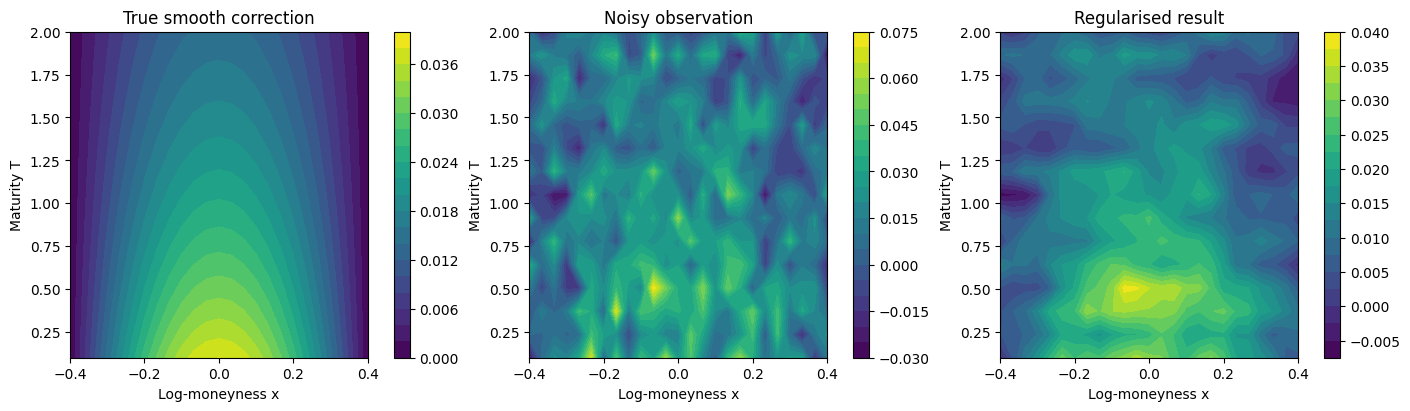

In [12]:
random_generator = np.random.default_rng(1234)

noisy_observation = (
    smooth_correction
    + random_generator.normal(
        loc=0.0,
        scale=0.015,
        size=smooth_correction.shape,
    )
)

regularization_strength = 0.20

identity = eye(
    number_of_unknowns,
    format="csc",
)

denoised_vector = spsolve(
    identity
    + regularization_strength
    * regularization_matrix,
    noisy_observation.reshape(-1, order="C"),
)

denoised_correction = denoised_vector.reshape(
    smooth_correction.shape,
    order="C",
)

noisy_rmse = np.sqrt(
    np.mean(
        (noisy_observation - smooth_correction) ** 2
    )
)
denoised_rmse = np.sqrt(
    np.mean(
        (denoised_correction - smooth_correction) ** 2
    )
)

print(f"Noisy RMSE:    {noisy_rmse:.6f}")
print(f"Denoised RMSE: {denoised_rmse:.6f}")

figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.0),
    constrained_layout=True,
)

for axis, surface, title in [
    (
        axes[0],
        smooth_correction,
        "True smooth correction",
    ),
    (
        axes[1],
        noisy_observation,
        "Noisy observation",
    ),
    (
        axes[2],
        denoised_correction,
        "Regularised result",
    ),
]:
    contour = axis.contourf(
        x_grid,
        maturity_grid,
        surface,
        levels=20,
    )
    figure.colorbar(contour, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()

assert denoised_rmse < noisy_rmse


## Stage 5 result

We now have the full regularisation operator

$$
R
=
\beta I
+
\alpha_xD_x^\top D_x
+
\alpha_TD_T^\top D_T
+
\operatorname{diag}(V).
$$

Its components have clear roles:

- \(\beta I\): discourages unnecessarily large corrections;
- \(D_x^\top D_x\): discourages roughness across log-moneyness;
- \(D_T^\top D_T\): discourages roughness across maturity;
- \(V\): discourages corrections in wings or low-confidence regions.

The next stage will place this matrix inside the weighted linearised inverse
problem.
